In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl
import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import datetime

from BT.data_handler import TimeGrid
from BT.triggers import DateTrigger, DateTriggerRequirements
from BT.query_actions import AddQueryAction
from BT.query_strategy import QueryStrategy
from BT.query_engine import QueryDrivenBacktest
from BT.misc import ql_cal_date_range

from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

In [3]:
mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")

# Simple MtM of Spot 2s10s

In [8]:
curve_2s10s = IRSwapQuery(
    structure=IRSwapStructure.CURVE,
    value=IRSwapValue.NPV,
    curve="USD-SOFR-1D",
    structure_kwargs={"front_tenor": "2Y", "back_tenor": "10Y", "bpv": 100_000},
)

In [9]:
trade_date = datetime.date(2025, 9, 2)
trade_trigger = DateTrigger(
    DateTriggerRequirements(dates=[trade_date]),
    actions=[AddQueryAction(query=curve_2s10s)],
)

strategy = QueryStrategy(name="Simple-MtM-USD-SOFR-1D-2s10s-Y25", triggers=[trade_trigger])
tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=ql.UnitedStates(ql.UnitedStates.GovernmentBond),
        start=trade_date,
        end=datetime.date(2025, 9, 29),
    )
)

In [10]:
bt = QueryDrivenBacktest(time_grid=tg, mdp=mdp, strategy=strategy)
bt.run()

BACKTESTING...: 100%|██████████| 20/20 [00:01<00:00, 16.52step/s]


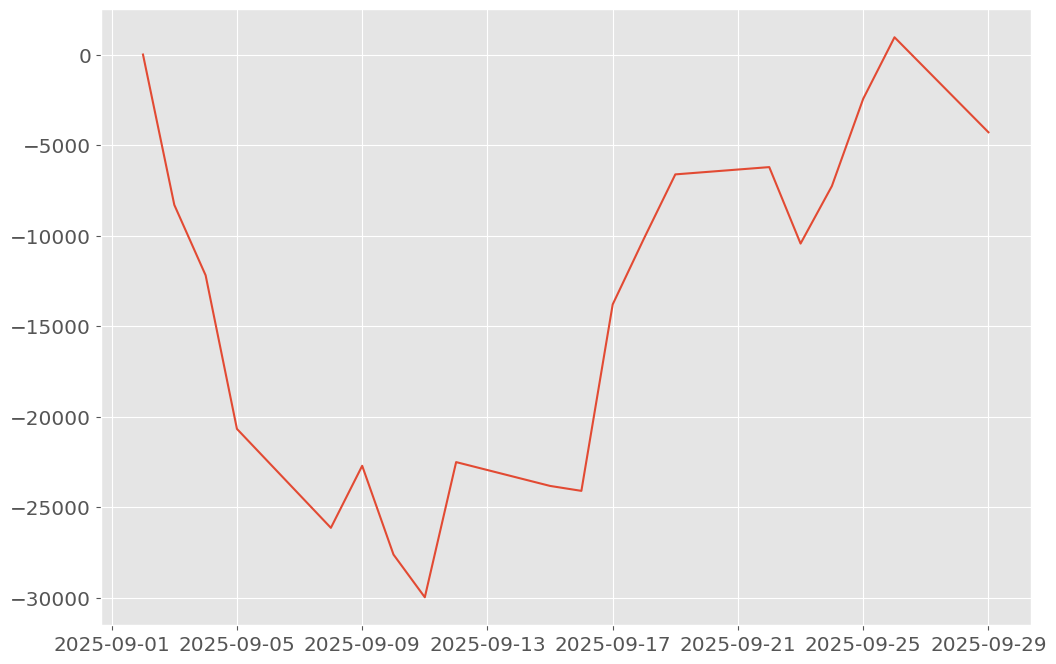

In [11]:
mtm = pd.Series(bt.mtm_history).sort_index()
plt.plot(mtm)